In [58]:
import os
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from PyLTSpice import RawRead, SimRunner, AscEditor

# 1. DEFINE YOUR REAL DATA POINTS
target_voltage = np.array([800., 850., 900., 950., 1000., 1050., 1100.])
# target_gain = np.array([4.79E+05, 6.93E+05, 9.81E+05, 1.36E+06, 1.86E+06, 2.51E+06, 3.32E+06])
target_gain = np.array([2.72E+05, 4.39E+05, 6.89E+05, 1.06E+06, 1.58E+06, 2.33E+06, 3.37E+06])


# Define filenames clearly
SCHEMATIC_NAME = "R12699 model - power law - S2 - gain optimization.asc"
OUTPUT_DIR = "./"

In [59]:
editor = AscEditor(SCHEMATIC_NAME)
print(editor.get_all_parameter_names())

['A', 'C_DYNODE', 'C_STORAGE', 'K', 'N_PE', 'R_0', 'V_0']


In [60]:
k, a = 0.08, 0.88

# Initialize the editor pointing to your schematic file
# Ensure you have your parameters wrapped as {k} and {a} inside the .asc file
editor = AscEditor(SCHEMATIC_NAME)
editor.set_parameter('A', a)
editor.set_parameter('K', k)

# Write the modified parameters to a temporary file for execution
run_schematic = os.path.join(OUTPUT_DIR, "sim_run.asc")
editor.save_as(run_schematic)

# Set up and execute the simulator runner
# Pass your LTspice executable explicitly if PyLTSpice cannot find it natively:
# runner = SimRunner(output_folder=OUTPUT_DIR, simulator=r"C:\Program Files\ADI\LTspice\LTspice.exe")
runner = SimRunner(output_folder=OUTPUT_DIR)

# Run simulation and fetch paths
raw_file, log_file = runner.run_now(run_schematic)

# Parse the raw results
LTR = RawRead(raw_file)

# Read traces directly using standard arrays
sim_time = LTR.get_trace('time').get_wave()
sim_current = np.abs(LTR.get_trace('I(V11)').get_wave())

sim_time, sim_current

KeyboardInterrupt: 

In [ ]:
# 2. SIMULATION WRAPPER FUNCTION USING CORRECT CLASSES
def run_ltspice_sim(params):
    k, a = params
    
    # Initialize the editor pointing to your schematic file
    # Ensure you have your parameters wrapped as {k} and {a} inside the .asc file
    editor = AscEditor(SCHEMATIC_NAME)
    editor.set_parameter('A', a)
    editor.set_parameter('K', k)

    # Write the modified parameters to a temporary file for execution
    run_schematic = os.path.join(OUTPUT_DIR, "sim_run.asc")
    editor.save_as(run_schematic)

    # Set up and execute the simulator runner
    # Pass your LTspice executable explicitly if PyLTSpice cannot find it natively:
    # runner = SimRunner(output_folder=OUTPUT_DIR, simulator=r"C:\Program Files\ADI\LTspice\LTspice.exe")
    runner = SimRunner(output_folder=OUTPUT_DIR)

    # Run simulation and fetch paths
    raw_file, log_file = runner.run_now(run_schematic)

    # Parse the raw results
    LTR = RawRead(raw_file)

    # In a .dc sweep, the independent axis ('v1' or 'v-sweep') replaces 'time'
    # Use LTR.get_trace_names() to double-check the axis name if it errors
    sim_voltage = LTR.get_trace('v1').get_wave() 
    sim_current = np.abs(LTR.get_trace('I(V11)').get_wave())
    sim_gain = sim_current / 1e-12  # Assuming input current is 1 pA for gain calculation
    
    return sim_voltage, sim_current, sim_gain

# 3. LOSS FUNCTION
def loss_function(params):
    input_current = 1e-12
    try:
        sim_voltage, sim_current, sim_gain = run_ltspice_sim(params)
        
        # Interpolate simulation data to line up with target data points
        sim_current_interpolated = np.interp(target_voltage, sim_voltage, sim_current)
        sim_gain_interpolated = sim_current_interpolated / input_current
        
        
        error = np.sum((np.log10(target_gain) - np.log10(sim_gain_interpolated)) ** 2)
        print(f"Testing: k={params[0]:.4f}, a={params[1]:.4f} -> Error (RSS): {error:.6e}")
        return error
    except Exception as e:
        print(f"Simulation failed for these values: {e}")
        return 1e10



In [ ]:
sim_voltage, sim_current, sim_gain = run_ltspice_sim([0.12, 0.8])
# Print table of voltages, currents, and gains
for v, i, g in zip(sim_voltage, sim_current, sim_gain):
    print(f"{v:.2f}\t\t{i:.2e}\t\t{g:.2e}")
    
# Now print out the target values in a new table
print("\nTarget Values:")
for v, g in zip(target_voltage, target_gain):
    print(f"{v:.2f}\t\t{g:.2e}")

800.00		3.32e-07		3.32e+05
850.00		5.40e-07		5.40e+05
900.00		8.53e-07		8.53e+05
950.00		1.32e-06		1.32e+06
1000.00		1.99e-06		1.99e+06
1050.00		2.94e-06		2.94e+06
1100.00		4.27e-06		4.27e+06

Target Values:
800.00		4.79e+05
850.00		6.93e+05
900.00		9.81e+05
950.00		1.36e+06
1000.00		1.86e+06
1050.00		2.51e+06
1100.00		3.32e+06


In [62]:
# Create the temporary simulation storage folder if missing
os.makedirs(OUTPUT_DIR, exist_ok=True)

initial_guess = [0.08, 0.88]
bounds = [(0.05, 0.15), (0.7, 1.0)]

print("Starting optimization loop...")
result = minimize(loss_function, initial_guess, bounds=bounds, method='Nelder-Mead')

best_k, best_a = result.x
print("\n=================================")
print("✅ OPTIMIZATION COMPLETE")
print(f"Best fit k: {best_k:.4f}")
print(f"Best fit a: {best_a:.4f}")
print("=================================\n")


Starting optimization loop...
Testing: k=0.0800, a=0.8800 -> Error (RSS): 1.408843e-01
Testing: k=0.0840, a=0.8800 -> Error (RSS): 5.419936e-02
Testing: k=0.0800, a=0.9240 -> Error (RSS): 3.565391e+00
Testing: k=0.0840, a=0.8360 -> Error (RSS): 4.112851e+00
Testing: k=0.0810, a=0.9020 -> Error (RSS): 8.354005e-01
Testing: k=0.0830, a=0.8580 -> Error (RSS): 1.110208e+00
Testing: k=0.0815, a=0.8910 -> Error (RSS): 1.877080e-01
Testing: k=0.0825, a=0.8690 -> Error (RSS): 3.255540e-01
Testing: k=0.0818, a=0.8855 -> Error (RSS): 4.317268e-02
Testing: k=0.0858, a=0.8855 -> Error (RSS): 5.348957e-01
Testing: k=0.0814, a=0.8814 -> Error (RSS): 1.988528e-02
Testing: k=0.0792, a=0.8869 -> Error (RSS): 3.061953e-02
Testing: k=0.0789, a=0.8828 -> Error (RSS): 1.590775e-01
Testing: k=0.0810, a=0.8848 -> Error (RSS): 1.506380e-02
Testing: k=0.0833, a=0.8793 -> Error (RSS): 1.728645e-02
Testing: k=0.0829, a=0.8827 -> Error (RSS): 4.879120e-02
Testing: k=0.0818, a=0.8817 -> Error (RSS): 1.327701e-02
T

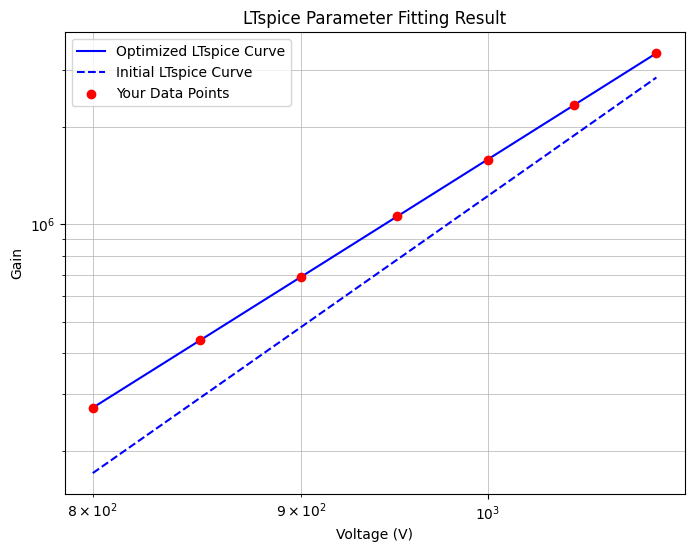

In [ ]:
initial_voltage, initial_current, initial_gain = run_ltspice_sim([0.08, 0.88])
final_voltage, final_current, final_gain = run_ltspice_sim([best_k, best_a])
plt.figure(figsize=(8, 6))
plt.plot(final_voltage, final_gain, label='Optimized LTspice Curve', color='blue')
plt.plot(initial_voltage, initial_gain, label='Initial LTspice Curve', color='blue', linestyle='--')
plt.scatter(target_voltage, target_gain, label='Your Data Points', color='red', zorder=5)
plt.xlabel('Voltage (V)')
plt.ylabel('Gain')
plt.title('LTspice Parameter Fitting Result')
plt.legend()
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.xscale('log')
plt.yscale('log')
